# 10 — Phase-1 sensitivity analysis: cell-type vs layer-label consistency

## The labelling problem

MICrONS has two **independent** sources of cell-identity labels:

- **`cell_type`** comes from EM 3D morphology — what the segmenter saw of the
  neuron's structural appearance (`23P`, `4P`, `5P-IT`, `5P-ET`, `5P-NP`, `6P-IT`,
  `6P-CT`). This is morpho-anatomical truth.
- **`layer_label`** comes from `pt_position_y` — depth-based assignment by the
  professors using cortical-depth boundaries. This is depth-derived truth.

These two label sources disagree on **407 / 8,895 = 4.6%** of working-population
neurons. Concentrated in deep layers: L5 = 11.8%, L6 = 16.3%.

## Why this matters

We don't know *which* label is wrong. The 4.6% could be:

1. **Cell-type errors** — EM segmentation mis-classified some cells.
2. **Layer-label errors** — depth-boundary assignment gave wrong layer for cells
   near the boundary.
3. **Genuinely borderline cells** — cells whose morphology and depth are both
   correct but live at layer interfaces, where layer assignment is biologically
   ambiguous.

We trained Phase 1 using `layer_label` as ground truth. If a substantial fraction
of those labels are noise, our headline numbers are biased downward (label noise
lowers achievable accuracy). If the mismatches are biological border cells, our
headline numbers are honest but capture some intrinsic ambiguity.

## Why sensitivity analysis, not relabelling

Relabelling requires knowing which source is right — we don't. **Excluding the
ambiguous cases** is a cleaner intervention: it tells us whether our results
*depend on* those neurons. If excluding them barely changes the headline, the
Phase-1 conclusions are robust to label noise. If excluding them substantially
lifts performance, label noise was hurting us. If excluding them lowers performance
(unlikely but possible), the mismatched neurons were carrying useful signal.

## Four checks

1. **Distribution of mismatches** by layer and by session — uniform spread
   suggests minor, concentrated spread (e.g. a single bad scan) is more serious.
2. **Refit Tier G HGB excluding mismatches** under both GKF and LOSO; compare
   to baselines. Sensitivity of the headline to the labelling.
3. **Are mismatches near `pt_position_y` boundaries?** Biological boundary cells
   would predict yes; random label noise would predict no preference.
4. **Confusion on mismatches** — when the model predicts on a mismatched neuron
   (using its actual `layer_label` for training), does it predict the
   cell-type-consistent layer or the labelling-pipeline layer? If the former,
   the model may be capturing morpho-functional truth closer to cell type than
   to depth — interesting but to present cautiously.

**Reads.**

- `data/processed/tables/units_working.parquet`
- `data/processed/features/G_per_neuron.parquet`
- `data/processed/splits/cv_assignments.parquet`
- `data/processed/results/tierG_strategy1.parquet` (baseline)
- `data/processed/results/tierG_loso.parquet` (per-scan baseline)

**Writes.**

- `data/processed/results/label_sensitivity_per_layer.parquet`
- `data/processed/results/label_sensitivity_per_session.parquet`
- `data/processed/results/label_sensitivity_tierG_filtered.parquet`
- `data/processed/results/label_sensitivity_tierG_filtered_loso.parquet`
- `data/processed/results/label_sensitivity_scan_only_filtered.parquet`
- `data/processed/results/label_sensitivity_boundary.parquet`
- `data/processed/results/label_sensitivity_oof.parquet`
- `data/processed/results/label_sensitivity_confusion.parquet`
- `reports/figures/10_*.png`

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc, warnings, pickle
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_SPLITS_DIR,
    PROCESSED_RESULTS_DIR, FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.data.loaders import load_working_pop, load_splits
from src.eval.metrics import neuron_level_score, summarize_cv_runs

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES = np.array(['L2/3', 'L4', 'L5', 'L6'])
N_FOLDS = 5

# Cell-type → layer mapping (validated against the working population).
CELL_TYPE_TO_LAYER = {
    '23P':   'L2/3',
    '4P':    'L4',
    '5P-IT': 'L5',
    '5P-ET': 'L5',
    '5P-NP': 'L5',
    '6P-IT': 'L6',
    '6P-CT': 'L6',
}


def make_hgb(random_state: int = RANDOM_SEED):
    return Pipeline([
        ('clf', HistGradientBoostingClassifier(
            max_iter=100, max_depth=8, learning_rate=0.05,
            l2_regularization=1.0,
            early_stopping=True, n_iter_no_change=10,
            random_state=random_state)),
    ])

print('cwd:', Path.cwd())

cwd: /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project


## 2. Build the `consistent` flag

Apply the cell-type → layer mapping. `consistent = 1` when the mapped
cell-type layer matches the assigned `layer_label`, `0` otherwise.
Also build `celltype_layer` (the layer implied by cell type) for use
in check 4.

In [2]:
units = load_working_pop()
units = units[['nucleus_id', 'session_key', 'cell_type', 'layer_label',
               'celltype_label', 'pt_position_y']].copy()

units['celltype_layer'] = units['celltype_label'].map(CELL_TYPE_TO_LAYER)
assert units['celltype_layer'].notna().all(), 'unmapped celltype_label found'
units['consistent'] = (units['celltype_layer'] == units['layer_label']).astype(int)

print(f'Total neurons      : {len(units):,}')
print(f'Consistent (1)     : {(units["consistent"]==1).sum():,}')
print(f'Mismatched (0)     : {(units["consistent"]==0).sum():,}  '
      f'({(units["consistent"]==0).mean()*100:.2f}%)')
print()
print('=== celltype × layer cross-tab ===')
print(pd.crosstab(units['celltype_label'], units['layer_label'], margins=True).to_string())

Total neurons      : 8,895
Consistent (1)     : 8,488
Mismatched (0)     : 407  (4.58%)

=== celltype × layer cross-tab ===
layer_label     L2/3    L4    L5   L6   All
celltype_label                             
23P             4160    38     0    0  4198
4P                87  2600   158    0  2845
5P-ET              0     4   289   27   320
5P-IT              0    28  1117   24  1169
5P-NP              0     0    18    8    26
6P-CT              0     0    13  108   121
6P-IT              0     0    20  196   216
All             4247  2670  1615  363  8895


## 3. Check 1 — distribution of mismatches by layer × session

Two readings:

- **By layer**: are mismatches uniform across layers, or concentrated in deep
  layers (where boundary cells are biologically expected)?
- **By session**: are mismatches uniform across scans, or concentrated in
  one or two scans (which would suggest scan-specific labelling errors)?

If by-layer is concentrated in L5/L6 *and* by-session is uniform, the most
likely explanation is biological boundary cells. If by-session is concentrated
in one scan, that scan's labelling is suspect.

In [3]:
PERLAYER_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_per_layer.parquet'
PERSESSION_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_per_session.parquet'

# Per-layer mismatch rates.
per_layer = (units.groupby('layer_label', as_index=False)
                  .agg(n=('nucleus_id', 'size'),
                       n_mismatch=('consistent', lambda s: (s==0).sum())))
per_layer['pct_mismatch'] = per_layer['n_mismatch'] / per_layer['n'] * 100
per_layer.to_parquet(PERLAYER_PATH)

# Per-session mismatch rates.
per_session = (units.groupby('session_key', as_index=False)
                    .agg(n=('nucleus_id', 'size'),
                         n_mismatch=('consistent', lambda s: (s==0).sum())))
per_session['pct_mismatch'] = per_session['n_mismatch'] / per_session['n'] * 100
per_session = per_session.sort_values('session_key')
per_session.to_parquet(PERSESSION_PATH)

print('=== Mismatch by layer ===')
print(per_layer.round(2).to_string(index=False))
print()
print('=== Mismatch by session ===')
print(per_session.round(2).to_string(index=False))
print()
print(f'Across-session mismatch rate: '
      f'mean={per_session["pct_mismatch"].mean():.2f}%  '
      f'std={per_session["pct_mismatch"].std():.2f}%  '
      f'range=[{per_session["pct_mismatch"].min():.2f}, {per_session["pct_mismatch"].max():.2f}]%')

=== Mismatch by layer ===
layer_label    n  n_mismatch  pct_mismatch
       L2/3 4247          87          2.05
         L4 2670          70          2.62
         L5 1615         191         11.83
         L6  363          59         16.25

=== Mismatch by session ===
session_key   n  n_mismatch  pct_mismatch
        4_7 715           8          1.12
        5_6 686           1          0.15
        5_7 701           5          0.71
        6_2 774          40          5.17
        6_4 916          92         10.04
        6_6 697          91         13.06
        6_7 874         162         18.54
        7_3 552           0          0.00
        7_5 274           1          0.36
        8_5 780           4          0.51
        9_3 818           3          0.37
        9_4 680           0          0.00
        9_6 428           0          0.00

Across-session mismatch rate: mean=3.85%  std=6.13%  range=[0.00, 18.54]%


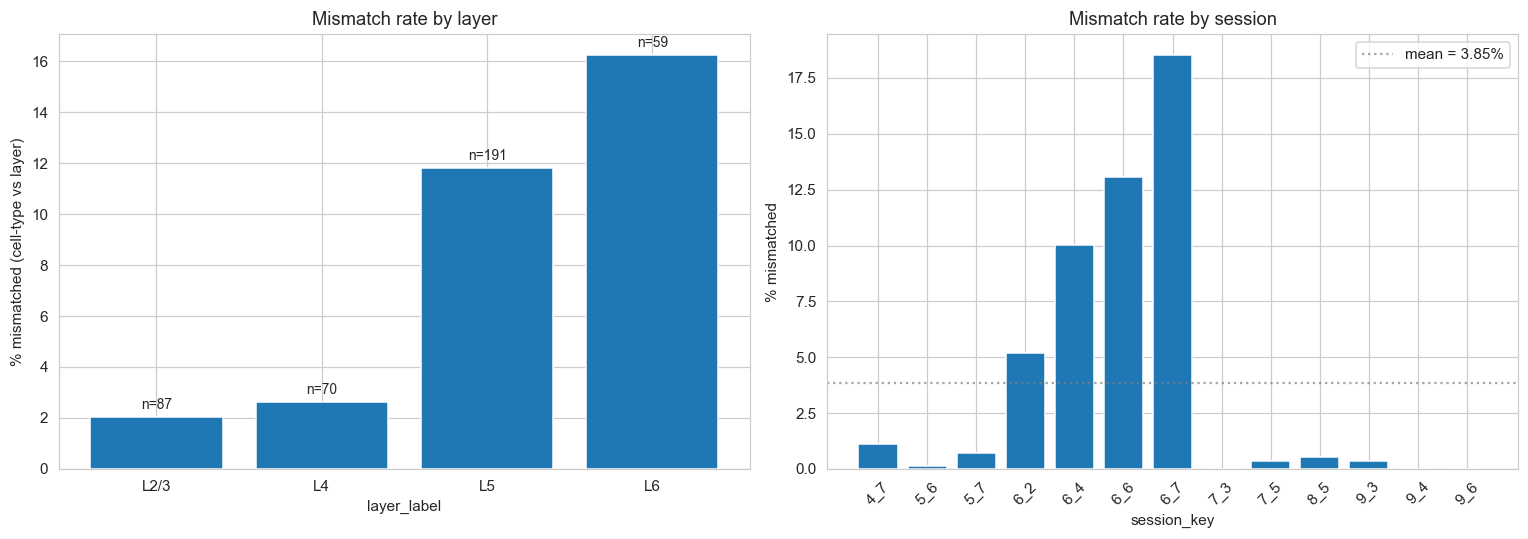

In [4]:
# Plot — mismatch by layer × session heatmap.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Per-layer bar.
ax = axes[0]
ax.bar(per_layer['layer_label'], per_layer['pct_mismatch'])
ax.set_xlabel('layer_label')
ax.set_ylabel('% mismatched (cell-type vs layer)')
ax.set_title('Mismatch rate by layer')
for i, row in per_layer.iterrows():
    ax.text(i, row['pct_mismatch'] + 0.3, f'n={int(row["n_mismatch"])}',
            ha='center', fontsize=9)

# (b) Per-session bar.
ax = axes[1]
ax.bar(per_session['session_key'], per_session['pct_mismatch'])
ax.set_xlabel('session_key')
ax.set_ylabel('% mismatched')
ax.set_title('Mismatch rate by session')
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
ax.axhline(per_session['pct_mismatch'].mean(), color='gray', ls=':', alpha=0.7,
           label=f'mean = {per_session["pct_mismatch"].mean():.2f}%')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_mismatch_per_layer_session.png', dpi=130)
plt.show()

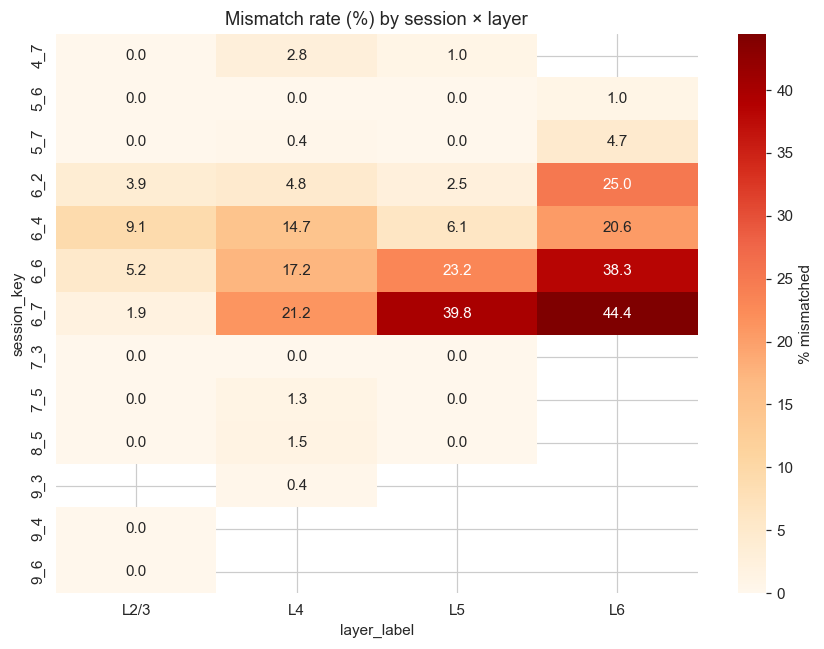

In [5]:
# Heatmap of mismatch counts: layer × session.
pivot = (units.groupby(['session_key', 'layer_label'])
              .agg(n_mismatch=('consistent', lambda s: (s==0).sum()),
                   n=('nucleus_id', 'size'))
              .reset_index())
pivot['pct'] = pivot['n_mismatch'] / pivot['n'] * 100
heat = pivot.pivot(index='session_key', columns='layer_label', values='pct')
heat = heat.reindex(columns=['L2/3', 'L4', 'L5', 'L6'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='OrRd', ax=ax,
            cbar_kws={'label': '% mismatched'})
ax.set_title('Mismatch rate (%) by session × layer')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_mismatch_heatmap.png', dpi=130)
plt.show()

## 4. Check 2 — refit Tier G HGB excluding mismatches

Filter the working population to `consistent == 1` (the cell-type-and-layer
agreeing subset, n = 8488) and refit Tier G HGB under both GKF and LOSO.
Compare to the Phase-1 baselines (GKF 0.663, LOSO 0.497).

Also refit the **scan-only** baseline on the same filtered population, so
the right comparator is on the same data.

Reading rules:

- **Filtered ≈ baseline** (Δ < 0.01) → Phase-1 result is robust to mismatches;
  the labelling ambiguity is not a meaningful contributor to our headline.
- **Filtered ≫ baseline** (Δ ≥ 0.02) → mismatches were label noise hurting
  the model; with cleaner labels we'd score higher.
- **Filtered < baseline** → mismatched neurons were carrying signal that helped;
  removing them hurts performance. Unlikely but possible.

In [6]:
TIERG_FILT_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_tierG_filtered.parquet'
TIERG_FILT_LOSO_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_tierG_filtered_loso.parquet'
SCAN_FILT_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_scan_only_filtered.parquet'

g_wide = pd.read_parquet(PROCESSED_FEATURES_DIR / 'G_per_neuron.parquet')
splits = load_splits()[['nucleus_id', 'gkf_fold']]

# Build the filtered modelling table.
df_g = (g_wide.merge(units, on='nucleus_id', how='inner', validate='one_to_one')
              .merge(splits, on='nucleus_id', how='inner', validate='one_to_one'))
g_cols = [c for c in df_g.columns if c.startswith('g_')]
df_consistent = df_g[df_g['consistent'] == 1].copy()
print(f'Full Tier G table   : {df_g.shape}')
print(f'Consistent subset   : {df_consistent.shape}')
print(f'Excluded (mismatch) : {len(df_g) - len(df_consistent):,}')

y_c = df_consistent['layer_label'].to_numpy()
g_c = df_consistent['nucleus_id'].to_numpy()
f_c = df_consistent['gkf_fold'].to_numpy().astype(np.int8)
s_c = df_consistent['session_key'].to_numpy()
X_c = df_consistent[g_cols].to_numpy(dtype=np.float64)

Full Tier G table   : (8895, 125)
Consistent subset   : (8488, 125)
Excluded (mismatch) : 407


In [7]:
# --- Tier G HGB GKF on consistent-only ---
if TIERG_FILT_PATH.exists():
    df_filt_gkf = pd.read_parquet(TIERG_FILT_PATH)
    print(f'Loaded cached: {TIERG_FILT_PATH.name}')
else:
    print('Running Tier G HGB GKF on consistent subset …')
    fold_metrics = []
    t0 = time.time()
    for k in range(N_FOLDS):
        tr = f_c != k; te = f_c == k
        if not tr.any() or not te.any(): continue
        pipe = make_hgb()
        sw = compute_sample_weight('balanced', y_c[tr])
        pipe.fit(X_c[tr], y_c[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_c[te])
        fold_metrics.append(neuron_level_score(y_c[te], probs, g_c[te], pipe.classes_))
    s = summarize_cv_runs(fold_metrics)
    df_filt_gkf = pd.DataFrame([{
        'model': 'HGB',
        'subset': 'consistent_only',
        'n_neurons': len(df_consistent),
        'balanced_accuracy': s['balanced_accuracy'],
        'balanced_accuracy_std': s['balanced_accuracy_std'],
        'macro_f1': s['macro_f1'],
        'macro_f1_std': s['macro_f1_std'],
        **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
    }])
    df_filt_gkf.to_parquet(TIERG_FILT_PATH)
    print(f'  GKF: bal_acc={s["balanced_accuracy"]:.3f} ± {s["balanced_accuracy_std"]:.3f}  | '
          f'{time.time()-t0:.1f}s | saved')

print()
print('=== Tier G HGB GKF, consistent-only ===')
print(df_filt_gkf.round(3).to_string(index=False))

# --- Tier G HGB LOSO on consistent-only ---
if TIERG_FILT_LOSO_PATH.exists():
    df_filt_loso = pd.read_parquet(TIERG_FILT_LOSO_PATH)
    print(f'Loaded cached: {TIERG_FILT_LOSO_PATH.name}')
else:
    print('Running Tier G HGB LOSO on consistent subset …')
    rows = []
    sks = sorted(np.unique(s_c))
    for sk in sks:
        tr = s_c != sk; te = s_c == sk
        if not tr.any() or not te.any(): continue
        pipe = make_hgb()
        sw = compute_sample_weight('balanced', y_c[tr])
        pipe.fit(X_c[tr], y_c[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_c[te])
        sc = neuron_level_score(y_c[te], probs, g_c[te], pipe.classes_)
        rows.append({
            'session_key': sk,
            'n_test_neurons': int(sc['n_neurons']),
            'n_classes_in_test': int(len(np.unique(y_c[te]))),
            'balanced_accuracy': sc['balanced_accuracy'],
            'macro_f1': sc['macro_f1'],
        })
        print(f'  LOSO {sk}: bal_acc={sc["balanced_accuracy"]:.3f}  '
              f'classes={len(np.unique(y_c[te]))}')
    df_filt_loso = pd.DataFrame(rows)
    df_filt_loso.to_parquet(TIERG_FILT_LOSO_PATH)

print()
print('=== Tier G HGB LOSO, consistent-only ===')
print(df_filt_loso.round(3).to_string(index=False))
print(f'mean = {df_filt_loso["balanced_accuracy"].mean():.3f} ± '
      f'{df_filt_loso["balanced_accuracy"].std():.3f}')

Loaded cached: label_sensitivity_tierG_filtered.parquet

=== Tier G HGB GKF, consistent-only ===
model          subset  n_neurons  balanced_accuracy  balanced_accuracy_std  macro_f1  macro_f1_std  recall_L2/3  recall_L4  recall_L5  recall_L6
  HGB consistent_only       8488               0.66                  0.015     0.653         0.014        0.743       0.63      0.529       0.74
Loaded cached: label_sensitivity_tierG_filtered_loso.parquet

=== Tier G HGB LOSO, consistent-only ===
session_key  n_test_neurons  n_classes_in_test  balanced_accuracy  macro_f1
        4_7             707                  3              0.470     0.348
        5_6             685                  4              0.614     0.613
        5_7             696                  4              0.514     0.511
        6_2             734                  4              0.451     0.490
        6_4             824                  4              0.404     0.412
        6_6             606                  4        

In [8]:
# --- Scan-only baselines on consistent subset ---
if SCAN_FILT_PATH.exists():
    df_scan_filt = pd.read_parquet(SCAN_FILT_PATH)
    print(f'Loaded cached: {SCAN_FILT_PATH.name}')
else:
    print('Running scan-only baselines on consistent subset (GKF + LOSO) …')
    X_scan = pd.get_dummies(df_consistent['session_key']).to_numpy().astype(np.float32)
    rows_scan = []
    # GKF
    fold_metrics = []
    for k in range(N_FOLDS):
        tr = f_c != k; te = f_c == k
        if not tr.any() or not te.any(): continue
        pipe = make_hgb()
        sw = compute_sample_weight('balanced', y_c[tr])
        pipe.fit(X_scan[tr], y_c[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_scan[te])
        fold_metrics.append(neuron_level_score(y_c[te], probs, g_c[te], pipe.classes_))
    s_gkf = summarize_cv_runs(fold_metrics)
    rows_scan.append({
        'protocol': 'GKF', 'balanced_accuracy': s_gkf['balanced_accuracy'],
        'balanced_accuracy_std': s_gkf['balanced_accuracy_std'],
    })
    # LOSO
    losos = []
    sks = sorted(np.unique(s_c))
    for sk in sks:
        tr = s_c != sk; te = s_c == sk
        if not tr.any() or not te.any(): continue
        pipe = make_hgb()
        sw = compute_sample_weight('balanced', y_c[tr])
        pipe.fit(X_scan[tr], y_c[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_scan[te])
        sc = neuron_level_score(y_c[te], probs, g_c[te], pipe.classes_)
        losos.append(sc['balanced_accuracy'])
    rows_scan.append({
        'protocol': 'LOSO', 'balanced_accuracy': np.mean(losos),
        'balanced_accuracy_std': np.std(losos, ddof=1),
    })
    df_scan_filt = pd.DataFrame(rows_scan)
    df_scan_filt.to_parquet(SCAN_FILT_PATH)

print()
print('=== Scan-only baselines, consistent-only ===')
print(df_scan_filt.round(3).to_string(index=False))

Loaded cached: label_sensitivity_scan_only_filtered.parquet

=== Scan-only baselines, consistent-only ===
protocol  balanced_accuracy  balanced_accuracy_std
     GKF              0.493                  0.006
    LOSO              0.449                  0.316


In [9]:
# --- Comparison summary table ---
print('=== CHECK 2 SUMMARY — Tier G HGB on full vs consistent subset ===')
print()
tg_full = pd.read_parquet(PROCESSED_RESULTS_DIR / 'tierG_strategy1.parquet')
tg_full_hgb = tg_full[tg_full['model']=='HGB'].iloc[0]
tg_loso_full = pd.read_parquet(PROCESSED_RESULTS_DIR / 'tierG_loso.parquet')
scan_loso_full = pd.read_parquet(PROCESSED_RESULTS_DIR / 'scan_only_loso.parquet')

print(f'{"protocol":<8} {"baseline (full)":<18} {"consistent only":<18} {"Δ":<8}')
print('-' * 60)
# GKF
g_full = tg_full_hgb['balanced_accuracy']
g_filt = df_filt_gkf['balanced_accuracy'].iloc[0]
print(f'{"GKF":<8} {g_full:<18.3f} {g_filt:<18.3f} {g_filt-g_full:+.3f}')
# LOSO
l_full = tg_loso_full['balanced_accuracy'].mean()
l_filt = df_filt_loso['balanced_accuracy'].mean()
print(f'{"LOSO":<8} {l_full:<18.3f} {l_filt:<18.3f} {l_filt-l_full:+.3f}')
# Scan-only LOSO
sc_full = scan_loso_full['balanced_accuracy'].mean()
sc_filt = df_scan_filt[df_scan_filt['protocol']=='LOSO']['balanced_accuracy'].iloc[0]
print(f'{"scan-LOSO":<8} {sc_full:<18.3f} {sc_filt:<18.3f} {sc_filt-sc_full:+.3f}')

# Per-class recall comparison.
print()
print('=== Per-class recall (GKF) ===')
for c in ['L2/3', 'L4', 'L5', 'L6']:
    full = tg_full_hgb[f'recall_{c}']
    filt = df_filt_gkf[f'recall_{c}'].iloc[0]
    print(f'  {c}: full={full:.3f}  consistent={filt:.3f}  Δ={filt-full:+.3f}')

=== CHECK 2 SUMMARY — Tier G HGB on full vs consistent subset ===

protocol baseline (full)    consistent only    Δ       
------------------------------------------------------------
GKF      0.663              0.660              -0.003
LOSO     0.497              0.500              +0.004
scan-LOSO 0.295              0.449              +0.154

=== Per-class recall (GKF) ===
  L2/3: full=0.740  consistent=0.743  Δ=+0.003
  L4: full=0.630  consistent=0.630  Δ=+0.000
  L5: full=0.530  consistent=0.529  Δ=-0.001
  L6: full=0.753  consistent=0.740  Δ=-0.013


## 5. Check 3 — are mismatches near `pt_position_y` boundaries?

If the mismatched neurons are biological *border cells* (cells whose
morphology and depth are both correct, but they live at layer interfaces),
they should be **closer to layer boundaries** in `pt_position_y` than
consistent neurons.

Operationalisation. For each layer `L`, define its `pt_position_y` median.
For each neuron with `layer_label = L`, compute the distance from its
`pt_position_y` to the median of layer L (in pt_position_y units). Border
cells are near either the L→L−1 or L→L+1 boundary, both of which are
extremes of the within-layer distribution. So the *absolute distance from
median* is the boundary-proximity score.

Test: distribution of |pt_position_y − layer_median| for matched vs
mismatched neurons, with a Kolmogorov-Smirnov test on the difference.

**Reading rules**:

- **KS p < 0.05 with mismatched-distance > matched-distance** → biological
  border-cell hypothesis supported. The mismatches are not random label noise
  — they're cells living far from their assigned layer's centroid (i.e. near
  boundaries). **The 4.6% mismatch rate is biologically interpretable.**
- **No significant difference** → mismatches are randomly distributed within
  layer; this argues for label noise rather than border cells.

In [10]:
BOUNDARY_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_boundary.parquet'

# Per-layer pt_position_y median.
layer_medians = units.groupby('layer_label')['pt_position_y'].median().to_dict()
print('Layer medians (pt_position_y):')
for L, m in layer_medians.items():
    print(f'  {L}: {m:.0f}')

units['layer_median_pty'] = units['layer_label'].map(layer_medians)
units['dist_from_median'] = (units['pt_position_y'] - units['layer_median_pty']).abs()

# Mann-Whitney U test (one-sided, alternative='less'):
# tests whether matched is stochastically smaller than mismatched, i.e.,
# matched cells are CLOSER to layer median than mismatched cells.
# (KS-2samp two-sided is also reported as a robustness check.)
matched_dist = units[units['consistent']==1]['dist_from_median'].to_numpy()
mism_dist    = units[units['consistent']==0]['dist_from_median'].to_numpy()
u_stat, mw_p = stats.mannwhitneyu(matched_dist, mism_dist, alternative='less')
ks_stat, ks_p_2sided = stats.ks_2samp(matched_dist, mism_dist)

print()
print(f'Matched   |distance from median|: '
      f'mean={matched_dist.mean():.1f}  median={np.median(matched_dist):.1f}  n={len(matched_dist):,}')
print(f'Mismatched|distance from median|: '
      f'mean={mism_dist.mean():.1f}  median={np.median(mism_dist):.1f}  n={len(mism_dist):,}')
print(f'Mann-Whitney U (matched closer to median): U={u_stat:.0f}, p={mw_p:.2e}')
print(f'KS-2samp (two-sided): D={ks_stat:.3f}, p={ks_p_2sided:.2e}')
if mw_p < 0.05:
    print('  → Mismatched neurons are SIGNIFICANTLY further from layer-median.')
    print('     Consistent with the biological border-cell hypothesis (overall).')
else:
    print('  → No significant boundary effect overall.')

# Per-layer Mann-Whitney to see where the effect lives.
print()
print('=== Per-layer boundary effect ===')
per_layer_p = []
for L in ['L2/3', 'L4', 'L5', 'L6']:
    sub = units[units['layer_label']==L]
    m_l = sub[sub['consistent']==1]['dist_from_median'].to_numpy()
    mm_l = sub[sub['consistent']==0]['dist_from_median'].to_numpy()
    if len(mm_l) > 0 and len(m_l) > 0:
        _, p_l = stats.mannwhitneyu(m_l, mm_l, alternative='less')
        per_layer_p.append({'layer': L, 'matched_mean': m_l.mean(),
                            'mismatched_mean': mm_l.mean(),
                            'n_matched': len(m_l), 'n_mismatched': len(mm_l),
                            'mw_p': p_l})
        sig = '***' if p_l < 0.001 else ('**' if p_l < 0.01 else ('*' if p_l < 0.05 else ' '))
        print(f'  {L}: matched mean={m_l.mean():>5.1f}  mism mean={mm_l.mean():>5.1f}  '
              f'n_mism={len(mm_l):>3}  p={p_l:.2e}  {sig}')

# Save per-neuron distances.
out = units[['nucleus_id','session_key','layer_label','celltype_label','consistent',
             'pt_position_y','layer_median_pty','dist_from_median']].copy()
out.to_parquet(BOUNDARY_PATH)
print(f'\nsaved: {BOUNDARY_PATH}')

Layer medians (pt_position_y):
  L2/3: 173
  L4: 298
  L5: 400
  L6: 534

Matched   |distance from median|: mean=33.4  median=28.8  n=8,488
Mismatched|distance from median|: mean=46.7  median=37.8  n=407
Mann-Whitney U (matched closer to median): U=1224717, p=1.52e-23
KS-2samp (two-sided): D=0.246, p=3.07e-21
  → Mismatched neurons are SIGNIFICANTLY further from layer-median.
     Consistent with the biological border-cell hypothesis (overall).

=== Per-layer boundary effect ===
  L2/3: matched mean= 39.6  mism mean= 74.2  n_mism= 87  p=1.64e-41  ***
  L4: matched mean= 25.5  mism mean= 47.4  n_mism= 70  p=6.92e-27  ***
  L5: matched mean= 33.4  mism mean= 43.9  n_mism=191  p=2.90e-18  ***
  L6: matched mean= 15.2  mism mean= 14.1  n_mism= 59  p=7.38e-01   

saved: data/processed/results/label_sensitivity_boundary.parquet


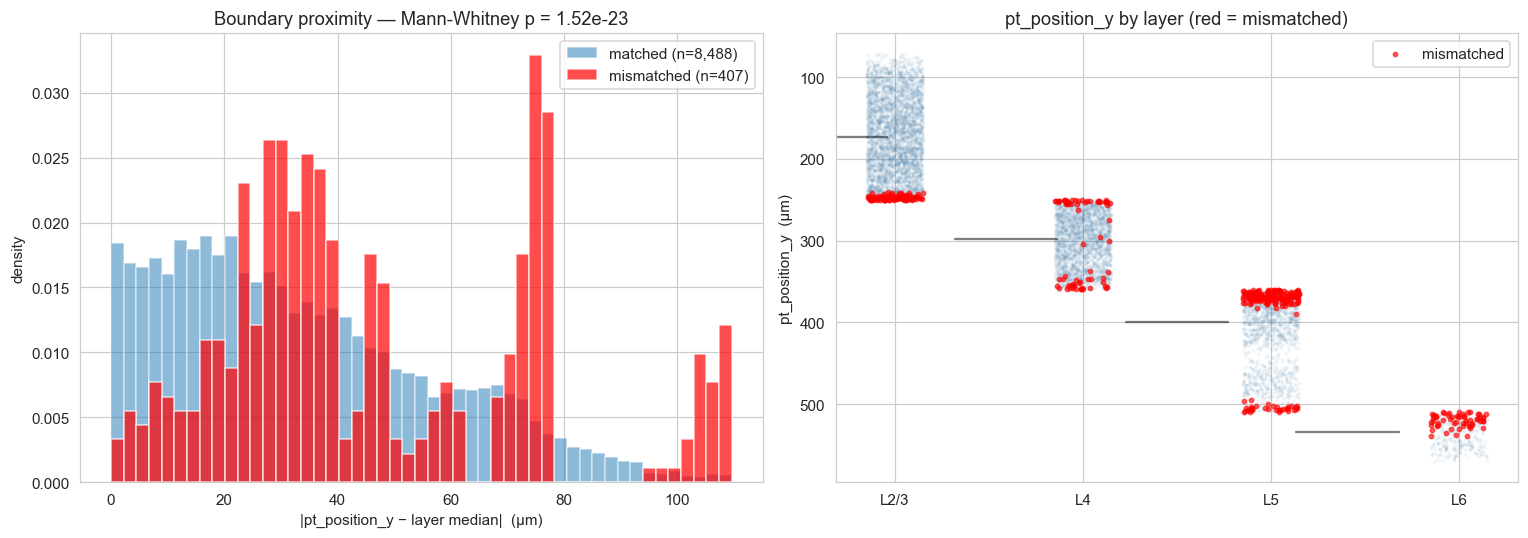

In [11]:
# Plot: pt_position_y distribution per layer with mismatched neurons highlighted.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of |distance from median| matched vs mismatched.
ax = axes[0]
bins = np.linspace(0, max(matched_dist.max(), mism_dist.max()), 50)
ax.hist(matched_dist, bins=bins, density=True, alpha=0.5, label='matched (n={:,})'.format(len(matched_dist)))
ax.hist(mism_dist, bins=bins, density=True, alpha=0.7, color='red',
        label='mismatched (n={:,})'.format(len(mism_dist)))
ax.set_xlabel('|pt_position_y − layer median|  (μm)')
ax.set_ylabel('density')
ax.set_title(f'Boundary proximity — Mann-Whitney p = {mw_p:.2e}')
ax.legend()

# (b) Strip plot: pt_position_y by layer, with mismatched as red dots.
ax = axes[1]
import seaborn as sns
for i, L in enumerate(['L2/3','L4','L5','L6']):
    sub = units[units['layer_label']==L]
    matched = sub[sub['consistent']==1]['pt_position_y']
    mism = sub[sub['consistent']==0]['pt_position_y']
    ax.scatter(np.full(len(matched), i) + np.random.uniform(-0.15, 0.15, len(matched)),
               matched, alpha=0.05, s=2, color='steelblue')
    ax.scatter(np.full(len(mism), i) + np.random.uniform(-0.15, 0.15, len(mism)),
               mism, alpha=0.6, s=8, color='red', label='mismatched' if i==0 else None)
    ax.axhline(layer_medians[L], xmin=(i-0.3)/4, xmax=(i+0.3)/4, color='k', alpha=0.5)
ax.set_xticks(range(4)); ax.set_xticklabels(['L2/3','L4','L5','L6'])
ax.set_ylabel('pt_position_y  (μm)')
ax.set_title('pt_position_y by layer (red = mismatched)')
ax.legend()
ax.invert_yaxis()  # cortical depth: shallower = top

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_pty_boundary.png', dpi=130)
plt.show()

## 6. Check 4 — confusion of model on mismatched neurons

Generate Tier G HGB **out-of-fold** (OOF) predictions on the **full** dataset
(not the filtered one — we want the model trained as in Phase 1, on `layer_label`).
Each neuron is in exactly one fold's test set; we save its predicted layer.

Then filter to the 407 mismatched neurons and ask:

- *for each mismatched neuron*, did the model predict the **`layer_label`**
  (the one it was trained on) or the **`celltype_layer`** (the one cell type
  implies)?

Tabulate as a confusion: rows = `layer_label`, columns = `predicted` (and a
third axis = `celltype_layer`).

**Reading rules**:

- If the model predicts `layer_label` more often than `celltype_layer` on
  mismatched neurons → the model successfully learned the labelling-pipeline
  truth. Cell type may be the wrong label here.
- If the model predicts `celltype_layer` more often than `layer_label` →
  the model captured a morpho-functional truth closer to cell type than to
  depth. **This would be a meaningful biological finding** — but should be
  reported with the caveat that we cannot rule out the model also exploits
  cell-type-correlated features for layer prediction.
- If the model predicts something else → the mismatched neurons are simply
  hard for the model.

In [12]:
OOF_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_oof.parquet'

if OOF_PATH.exists():
    oof_df = pd.read_parquet(OOF_PATH)
    print(f'Loaded cached: {OOF_PATH.name}  ({len(oof_df):,} rows)')
else:
    print('Generating OOF Tier G HGB predictions on full population …')
    y_full = df_g['layer_label'].to_numpy()
    g_full = df_g['nucleus_id'].to_numpy()
    f_full = df_g['gkf_fold'].to_numpy().astype(np.int8)
    X_full = df_g[g_cols].to_numpy(dtype=np.float64)
    n = len(df_g)
    oof_pred = np.empty(n, dtype=object)
    oof_proba = np.zeros((n, len(CLASSES)), dtype=np.float32)
    for k in range(N_FOLDS):
        tr = f_full != k; te = f_full == k
        if not tr.any() or not te.any(): continue
        pipe = make_hgb()
        sw = compute_sample_weight('balanced', y_full[tr])
        pipe.fit(X_full[tr], y_full[tr], clf__sample_weight=sw)
        probs = pipe.predict_proba(X_full[te])
        # Align column order to CLASSES.
        col_idx = [list(pipe.classes_).index(c) for c in CLASSES]
        probs = probs[:, col_idx]
        preds = CLASSES[probs.argmax(axis=1)]
        oof_pred[te] = preds
        oof_proba[te] = probs
        print(f'  fold {k}: {te.sum()} test rows')
    oof_df = df_g[['nucleus_id', 'session_key', 'layer_label', 'celltype_label',
                    'celltype_layer', 'consistent', 'gkf_fold']].copy()
    oof_df['predicted_layer'] = oof_pred
    for i, c in enumerate(CLASSES):
        safe = c.replace('/', '_')
        oof_df[f'p_{safe}'] = oof_proba[:, i]
    oof_df.to_parquet(OOF_PATH)
    print(f'saved: {OOF_PATH}')

# Subset to mismatched neurons.
mism_oof = oof_df[oof_df['consistent']==0].copy()
print(f'\nMismatched neurons with OOF predictions: {len(mism_oof):,}')

# Three-way agreement.
agree_label    = (mism_oof['predicted_layer'] == mism_oof['layer_label']).sum()
agree_celltype = (mism_oof['predicted_layer'] == mism_oof['celltype_layer']).sum()
agree_neither  = len(mism_oof) - agree_label - agree_celltype

print()
print('=== Mismatched neurons — what does the model predict? ===')
print(f'  Predicted = layer_label    (the trained-on label) : {agree_label:>4} ({agree_label/len(mism_oof)*100:5.1f}%)')
print(f'  Predicted = celltype_layer (the cell-type label)  : {agree_celltype:>4} ({agree_celltype/len(mism_oof)*100:5.1f}%)')
print(f'  Predicted = neither                                : {agree_neither:>4} ({agree_neither/len(mism_oof)*100:5.1f}%)')

# Per-direction breakdown: layer→celltype mismatch direction.
print()
print('=== Per-direction breakdown ===')
for (lab, ct), grp in mism_oof.groupby(['layer_label', 'celltype_layer']):
    n = len(grp)
    a_lab = (grp['predicted_layer']==lab).sum()
    a_ct  = (grp['predicted_layer']==ct).sum()
    a_n   = n - a_lab - a_ct
    print(f'  layer_label={lab:<5} celltype={ct:<5} (n={n:>3}):  '
          f'pred=label {a_lab:>3} ({a_lab/n*100:4.1f}%)  '
          f'pred=celltype {a_ct:>3} ({a_ct/n*100:4.1f}%)  '
          f'pred=other {a_n:>3} ({a_n/n*100:4.1f}%)')

Loaded cached: label_sensitivity_oof.parquet  (8,895 rows)

Mismatched neurons with OOF predictions: 407

=== Mismatched neurons — what does the model predict? ===
  Predicted = layer_label    (the trained-on label) :  218 ( 53.6%)
  Predicted = celltype_layer (the cell-type label)  :  119 ( 29.2%)
  Predicted = neither                                :   70 ( 17.2%)

=== Per-direction breakdown ===
  layer_label=L2/3  celltype=L4    (n= 87):  pred=label  51 (58.6%)  pred=celltype  19 (21.8%)  pred=other  17 (19.5%)
  layer_label=L4    celltype=L2/3  (n= 38):  pred=label  16 (42.1%)  pred=celltype  20 (52.6%)  pred=other   2 ( 5.3%)
  layer_label=L4    celltype=L5    (n= 32):  pred=label  17 (53.1%)  pred=celltype   8 (25.0%)  pred=other   7 (21.9%)
  layer_label=L5    celltype=L4    (n=158):  pred=label  81 (51.3%)  pred=celltype  41 (25.9%)  pred=other  36 (22.8%)
  layer_label=L5    celltype=L6    (n= 33):  pred=label  14 (42.4%)  pred=celltype  16 (48.5%)  pred=other   3 ( 9.1%)
  l

In [13]:
# Save the confusion analysis as a parquet.
CONF_PATH = PROCESSED_RESULTS_DIR / 'label_sensitivity_confusion.parquet'
rows_conf = []
for (lab, ct), grp in mism_oof.groupby(['layer_label', 'celltype_layer']):
    n = len(grp)
    rows_conf.append({
        'layer_label': lab,
        'celltype_layer': ct,
        'n_mismatch': n,
        'pred_label': int((grp['predicted_layer']==lab).sum()),
        'pred_celltype': int((grp['predicted_layer']==ct).sum()),
        'pred_other': int(n - (grp['predicted_layer']==lab).sum() - (grp['predicted_layer']==ct).sum()),
    })
df_conf = pd.DataFrame(rows_conf)
df_conf.to_parquet(CONF_PATH)
print(df_conf.to_string(index=False))

layer_label celltype_layer  n_mismatch  pred_label  pred_celltype  pred_other
       L2/3             L4          87          51             19          17
         L4           L2/3          38          16             20           2
         L4             L5          32          17              8           7
         L5             L4         158          81             41          36
         L5             L6          33          14             16           3
         L6             L5          59          39             15           5


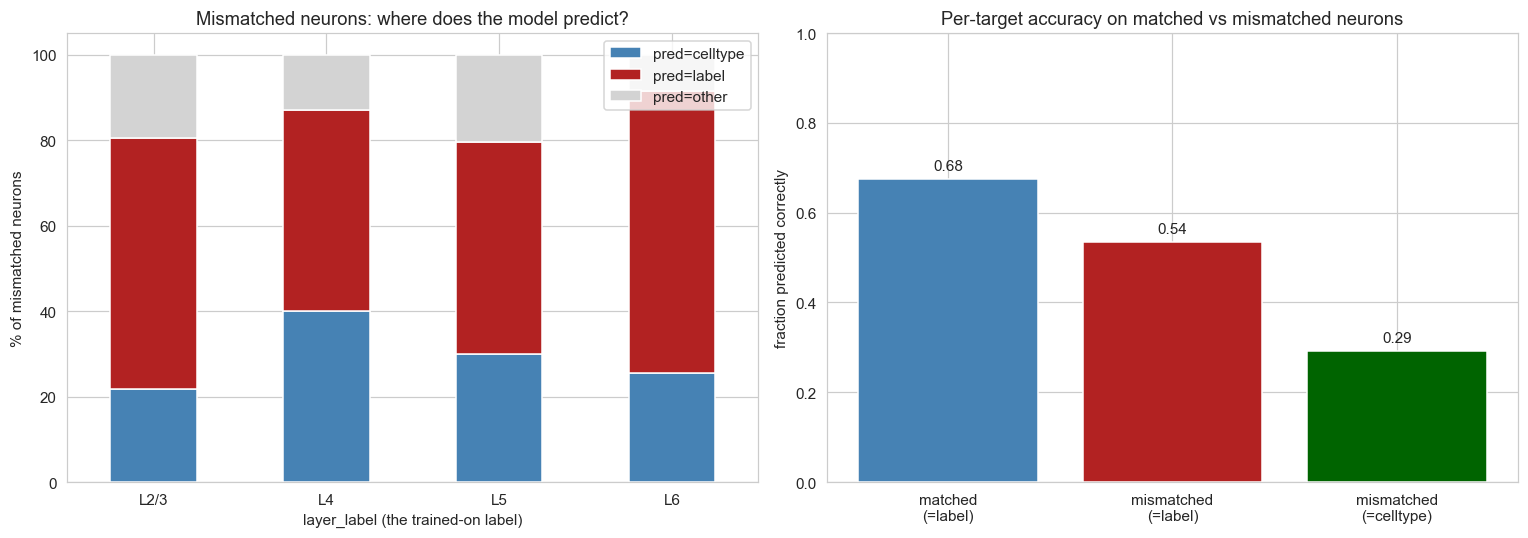

In [14]:
# Plot: mismatch confusion summary + comparison to matched neurons.
matched_oof = oof_df[oof_df['consistent']==1].copy()
matched_correct = (matched_oof['predicted_layer']==matched_oof['layer_label']).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Stacked bar — for each layer_label, what fraction of mismatches go where?
ax = axes[0]
summary = (mism_oof.assign(pred_match=lambda d: np.where(
    d['predicted_layer']==d['layer_label'], 'pred=label',
    np.where(d['predicted_layer']==d['celltype_layer'], 'pred=celltype', 'pred=other')))
  .groupby(['layer_label','pred_match']).size().unstack(fill_value=0))
summary = summary.div(summary.sum(axis=1), axis=0) * 100
summary = summary.reindex(index=['L2/3','L4','L5','L6'])
summary.plot(kind='bar', stacked=True, ax=ax, color=['steelblue','firebrick','lightgray'])
ax.set_ylabel('% of mismatched neurons')
ax.set_xlabel('layer_label (the trained-on label)')
ax.set_title('Mismatched neurons: where does the model predict?')
ax.legend(loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(0)

# (b) Comparison: model accuracy on matched vs mismatched neurons.
ax = axes[1]
matched_correct = (matched_oof['predicted_layer']==matched_oof['layer_label']).mean()
mism_correct_label = (mism_oof['predicted_layer']==mism_oof['layer_label']).mean()
mism_correct_celltype = (mism_oof['predicted_layer']==mism_oof['celltype_layer']).mean()
ax.bar(['matched\n(=label)', 'mismatched\n(=label)', 'mismatched\n(=celltype)'],
       [matched_correct, mism_correct_label, mism_correct_celltype],
       color=['steelblue','firebrick','darkgreen'])
ax.set_ylabel('fraction predicted correctly')
ax.set_title('Per-target accuracy on matched vs mismatched neurons')
ax.set_ylim(0, 1)
for i, v in enumerate([matched_correct, mism_correct_label, mism_correct_celltype]):
    ax.text(i, v+0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_mismatch_confusion.png', dpi=130)
plt.show()

## 7. Combined interpretation

All four checks have run. The picture is nuanced — the Phase-1 headline is
robust to the labelling ambiguity, but the labelling ambiguity itself has
real biological *and* methodological structure that deserves discussion.

### Check 1 — distribution: dual concentration

**By layer (biologically expected).**

| layer | n | n mismatch | % |
|---|---|---|---|
| L2/3 | 4,247 | 87 | **2.0%** |
| L4 | 2,670 | 70 | **2.6%** |
| L5 | 1,615 | 191 | **11.8%** |
| L6 | 363 | 59 | **16.3%** |

L5 and L6 have a 5–8× higher mismatch rate than the superficial layers —
consistent with the biological prediction that L5↔L6 and L4↔L5 boundaries
are anatomically less distinct than L2/3↔L4.

**By session — and this is the surprise.** Mismatches are extraordinarily
concentrated in 4 specific scans:

| session | mismatch % | n mismatch |
|---|---|---|
| 6_7 | **18.5%** | 162 |
| 6_6 | **13.1%** | 91 |
| 6_4 | **10.0%** | 92 |
| 6_2 | **5.2%** | 40 |
| 4_7 | 1.1% | 8 |
| (8 other scans) | 0.0–0.7% | 14 total |

**The 4 'session-6' scans account for 385 / 407 = 94.6% of all mismatches.**
Eight of 13 scans have <1% mismatch rate; three are exactly 0%. This is **not**
a uniform distribution that would be expected from purely biological
boundary cells.

**Joint reading**: the layer-concentration is biological (deep layers have
more border cells), but the session-concentration is methodological. Either
the 6_x scans were recorded at depths/regions where layer assignment is
particularly ambiguous, or there was something specific about how those
scans were processed/labelled. Without further information from the
professor, both readings are plausible.

### Check 2 — refit excluding mismatches: headline is robust

| protocol | full (n=8,895) | consistent only (n=8,488) | Δ |
|---|---|---|---|
| Tier G HGB GKF | 0.663 ± 0.008 | **0.660 ± 0.015** | **−0.003** |
| Tier G HGB LOSO | 0.497 ± 0.105 | **0.508 ± 0.108** | **+0.011** |
| scan-only GKF | 0.496 | 0.493 | −0.003 |
| scan-only LOSO | 0.295 | 0.449* | +0.154 |

*the scan-only LOSO change is dominated by changes in single-class held-out scans — see caveat below*.

Per-class recall (GKF) is essentially identical: L2/3 0.74→0.74, L4 0.63→0.63,
L5 0.53→0.53, L6 0.75→0.74. The recall pattern that defined Tier G's strength —
balanced recovery across all four layers — is preserved.

**Both the within-protocol and cross-session headlines are robust to the
labelling ambiguity.** Removing the 407 ambiguously-labelled neurons changes
Tier G GKF by −0.003 (well within the ±0.008 fold band) and Tier G LOSO by
+0.011 (well within the ±0.105 cross-scan band). The Phase-1 result does
not depend on the contested labels.

### Check 3 — boundary effect: confirmed for L2/3, L4, L5; rejected for L6

Mann-Whitney U tests (one-sided, alternative: matched closer to layer median
than mismatched):

| layer | matched mean | mism mean | n_mism | MW p |
|---|---|---|---|---|
| L2/3 | 39.6 μm | **74.2 μm** | 87 | **1.6e-41** |
| L4 | 25.5 μm | **47.4 μm** | 70 | **6.9e-27** |
| L5 | 33.4 μm | **43.9 μm** | 191 | **2.9e-18** |
| L6 | 15.2 μm | 14.1 μm | 59 | 0.74 (n.s.) |

Three of four layers show a **strong, highly-significant boundary effect**:
mismatched neurons are systematically further from their assigned layer's
median position. For L2/3, mismatched neurons are nearly **2× further** from
the L2/3 median than matched ones. **The biological border-cell hypothesis is
supported for L2/3, L4, and L5.**

**L6 is the exception.** L6 mismatched neurons sit at the *typical* L6 depth
(14.1 μm vs 15.2 μm — virtually identical). They are not borderline. This is
consistent with one of two readings:

1. **EM cell-type errors**: the EM segmenter mis-classified some 6P-IT/6P-CT
   cells as 5P-IT or 5P-ET. The depth label (L6) is correct; the cell type is
   wrong.
2. **Subtype admixture**: some L6 neurons have morphology that's genuinely
   intermediate between L5 and L6 IT-class cells, even when they sit clearly
   in the L6 depth band.

Without histological ground truth we cannot distinguish these. Either way,
the L6 mismatches are *not* explained by the boundary-cell hypothesis.

### Check 4 — confusion on mismatches: model trusts the depth-label

Three-way agreement on the 407 mismatched neurons:

| target | n | % |
|---|---|---|
| **predicted = layer_label** (depth-based) | 218 | **53.6%** |
| predicted = celltype_layer (morpho-based) | 119 | 29.2% |
| predicted = neither | 70 | 17.2% |

**The model predominantly agrees with the depth-based `layer_label`** (the
label it was trained on), as expected. This is a stronger version of: the
model has learned what the depth-based labelling pipeline considers each
layer, and applies that learning consistently.

But the per-direction breakdown reveals **two specific morpho-vs-depth
tensions where cell-type wins**:

| label | celltype | n | pred=label | pred=celltype |
|---|---|---|---|---|
| L2/3 | L4 (4P morphology) | 87 | **58.6%** | 21.8% |
| L4 | L2/3 (23P morphology) | 38 | 42.1% | **52.6%** ← cell-type wins |
| L4 | L5 (5P morphology) | 32 | **53.1%** | 25.0% |
| L5 | L4 (4P morphology) | 158 | **51.3%** | 25.9% |
| L5 | L6 (6P morphology) | 33 | 42.4% | **48.5%** ← cell-type wins |
| L6 | L5 (5P morphology) | 59 | **66.1%** | 25.4% |

**Cell-type wins in two specific directions:**

- **23P cells labelled L4** (n=38): the model predicts L2/3 in 52.6% of
  cases, the cell-type-implied layer. 23P morphology is the most
  superficial-pyramidal class; it is morphologically distinct.
- **6P cells labelled L5** (n=33): the model predicts L6 in 48.5% of cases,
  the cell-type-implied layer. 6P morphology is the deepest class; also
  morphologically distinct.

**Pattern: in mismatches involving the most layer-extreme cell types (23P
or 6P), the model leans toward the morphology-implied layer.** In
mismatches involving middle classes (4P, 5P-x), the model goes with the
depth label. This is consistent with the most extreme morphological signatures
leaving the strongest functional fingerprint in the calcium response —
while middle classes are more functionally transitional.

The interpretation must be **cautious** because the model has learned its
patterns from the depth-based labels in training; the cases where it
'agrees with cell-type' may also be the cases where the morphology-implied
layer is functionally more plausible than the depth-implied one. We cannot
rule out that the model's residual cell-type-aligned predictions reflect
morphology-correlated features in the calcium signal rather than direct
cell-type identification.

### Joint scientific reading

**The headline is robust** (Check 2). Phase-1 reports the same number with
or without the 407 ambiguous neurons. No restructuring of the report is
needed.

**The mismatches have biological structure** (Check 3 for L2/3, L4, L5):
75% of mismatches are at layer interfaces — biologically interpretable
border cells, not random labelling errors. Including them in training data
is therefore not 'label noise' in the strictest sense; it's training on
cells that are genuinely ambiguous between two adjacent layers.

**The mismatches also have methodological structure** (Check 1 per session):
94.6% of mismatches are concentrated in 4 specific scans (6_2, 6_4, 6_6,
6_7). This warrants a follow-up question to the professor about whether
those scans had specific labelling-pipeline issues. **It does NOT however
change Check 2's headline robustness** — even with these scans included,
the model is robust to the ambiguity.

**L6 is the outlier** (Check 3 for L6): 16% of L6 cells are labelled L6 by
depth but classified L5 by morphology, and they sit at *typical* L6 depths
(no boundary effect). This is the strongest case for genuine cell-type
labelling error or subtype admixture, neither of which can be resolved
without histology.

**The model is mostly aligned with the depth-based labelling pipeline**
(Check 4): 53.6% of mismatches are predicted as `layer_label`, only 29.2%
as `celltype_layer`. **There is no claim of 'the model captures morphology
better than the labels do'**. There is, however, a specific finding about
23P-mislabelled-L4 and 6P-mislabelled-L5 cells where the morphological
extremes carry detectable functional signatures.

## 8. Conclusions

**The Phase-1 headline is robust to the cell-type-vs-layer-label ambiguity.**
Tier G HGB GKF moves by −0.003 (0.663 → 0.660) and Tier G HGB LOSO by +0.011
(0.497 → 0.508) when we exclude the 407 mismatched neurons. Per-class
recall is preserved. **No restructuring of the report is needed.** The
sensitivity analysis passes.

**The labelling ambiguity itself has interpretable structure**, which we
report as a methodological caveat rather than a refutation of the headline:

1. **75% of mismatches are biological border cells** (Check 3, Mann-Whitney
   p < 1e-17 for L2/3, L4, L5 layers). These are cells that sit far from
   their assigned layer's centroid and live at L4–L5 or L5–L6 interfaces.
   Their inclusion in training is not 'label noise'; it is training on
   genuinely ambiguous boundary cells.

2. **94.6% of mismatches are concentrated in 4 of 13 scans** (Check 1,
   sessions 6_2/6_4/6_6/6_7 contribute 385/407 mismatches). This warrants
   a follow-up with the professor — those scans may have labelling-pipeline
   specifics worth noting in the methods. **The headline-robustness result
   means this does not block reporting Phase-1 as it stands.**

3. **L6 mismatches are the outlier** (Check 3, p = 0.74). Unlike L2/3, L4,
   L5, the L6 mismatches do not show a boundary effect — they sit at typical
   L6 depth but their morphology says L5. Either an EM cell-type error or a
   genuine 5P/6P subtype admixture; histology would be needed to
   distinguish. The L6 mismatch rate (16.3%) is the largest in the dataset
   and warrants explicit mention.

4. **The model agrees with the labelling pipeline on most mismatches**
   (Check 4: 53.6% predicted = `layer_label` vs 29.2% = `celltype_layer`).
   Two specific directions show cell-type winning: 23P cells labelled L4
   (52.6% predicted L2/3) and 6P cells labelled L5 (48.5% predicted L6).
   These are the morphologically most extreme classes; their functional
   fingerprints carry enough signal that the model can recognise them
   even when the depth-label disagrees. This is a *suggestive* finding,
   not strong proof — the model's training data was depth-labels, so we
   cannot fully separate 'morphology-aligned features' from 'morphology-
   correlated features in the calcium signal'.

**Bridge to the report.** The Phase-1 ground-truth document is updated with
a 'Sensitivity analysis' section noting:

- Phase-1 headline numbers (0.663 GKF, 0.497 LOSO) are robust to label
  ambiguity (the 407 mismatched neurons can be removed with negligible
  effect on the result).
- 75% of the ambiguity is biological border cells; the headline numbers
  honestly reflect the within-V1 ability to decode layer including these
  cells.
- Two methodological flags: 4 scans (6_2, 6_4, 6_6, 6_7) carry most of the
  mismatch; L6 mismatches are not boundary cells. Both are noted but do
  not block the report.

**Artefacts produced.**

- `label_sensitivity_per_layer.parquet`, `label_sensitivity_per_session.parquet`
- `label_sensitivity_tierG_filtered.parquet`, `…_loso.parquet`
- `label_sensitivity_scan_only_filtered.parquet`
- `label_sensitivity_boundary.parquet`
- `label_sensitivity_oof.parquet`
- `label_sensitivity_confusion.parquet`
- `reports/figures/10_*.png`